# From Bagging to Boosting: Understanding Gradient Boosting with XGBoost

## A Machine Learning Tutorial — Predicting Heart Failure Survival

**Author:** Osman Hussain Mohammed  
**Course:** Machine Learning, University of Hertfordshire (2025–2026)  
**GitHub Repository:** *[Insert your GitHub link here]*

---

### Tutorial Overview

This notebook accompanies the tutorial PDF and demonstrates how **Gradient Boosting** (Friedman, 2001), specifically **XGBoost** (Chen and Guestrin, 2016), works by building on concepts you already know — Decision Trees and Random Forests (Breiman, 2001). We use the [UCI Heart Failure Clinical Records Dataset](https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records) (Chicco and Jurman, 2020) to predict patient survival.

**References:**
1. Chen, T. and Guestrin, C. (2016) 'XGBoost: A Scalable Tree Boosting System', *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, pp. 785–794. doi:10.1145/2939672.2939785.
2. Friedman, J.H. (2001) 'Greedy Function Approximation: A Gradient Boosting Machine', *The Annals of Statistics*, 29(5), pp. 1189–1232.
3. Chicco, D. and Jurman, G. (2020) 'Machine learning can predict survival of patients with heart failure from serum creatinine and ejection fraction alone', *BMC Medical Informatics and Decision Making*, 20(16). doi:10.1186/s12911-020-1023-5.
4. Breiman, L. (2001) 'Random Forests', *Machine Learning*, 45(1), pp. 5–32. doi:10.1023/A:1010933404324.
5. Scikit-learn developers (2024) *Ensemble Methods — scikit-learn documentation*. Available at: https://scikit-learn.org/stable/modules/ensemble.html (Accessed: 15 March 2026).
6. XGBoost developers (2024) *XGBoost Documentation*. Available at: https://xgboost.readthedocs.io/ (Accessed: 15 March 2026).
7. UCI Machine Learning Repository (2020) *Heart Failure Clinical Records Dataset*. Available at: https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records (Accessed: 15 March 2026).

In [1]:
# ── Imports & Setup ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc, f1_score)
from xgboost import XGBClassifier

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Accessibility: colour-blind friendly palette
CB_PALETTE = sns.color_palette("colorblind")
sns.set_palette(CB_PALETTE)
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "figure.figsize": (10, 6),
    "figure.dpi": 100,
})

print("Setup complete ✓")

Setup complete ✓


## 1. The Journey: Decision Trees → Random Forests → Gradient Boosting

Before diving into code, let's understand **why** Gradient Boosting exists by tracing its lineage.

### Decision Trees — The Building Block
A single decision tree splits data by asking yes/no questions about features. They are intuitive but prone to **overfitting** — they memorise the training data rather than learning general patterns.

### Random Forests — Strength in Numbers (Bagging)
Random Forests fix overfitting by training **many trees in parallel** on random subsets of the data (**bootstrap aggregating**, or *bagging*) (Breiman, 2001). Each tree votes, and the majority wins. The errors of individual trees cancel out because they are **independent**.

> **Bagging idea:** Build many models *independently* and *average* their predictions (Breiman, 2001).

### Gradient Boosting — Learning from Mistakes
Gradient Boosting takes a fundamentally different approach. Instead of building trees in parallel, it builds them **sequentially**: each new tree focuses on correcting the **errors (residuals)** left by the previous ones (Friedman, 2001).

> **Boosting idea:** Build models *sequentially*, where each one fixes what the last one got wrong (Friedman, 2001).

| Property | Random Forest (Bagging) | Gradient Boosting |
|---|---|---|
| Tree training | Parallel, independent | Sequential, dependent |
| Focus | Reduce variance (Breiman, 2001) | Reduce bias (Friedman, 2001) |
| Overfitting risk | Lower | Higher (needs tuning) |
| Speed | Faster to train | Slower (sequential) |

In this tutorial we will implement all three approaches and see Gradient Boosting's advantage first-hand.

## 2. Loading and Exploring the Data

We use the **Heart Failure Clinical Records Dataset** from the UCI Machine Learning Repository (Chicco and Jurman, 2020). It contains medical records of 299 patients who experienced heart failure. Our goal is to predict whether a patient survived (`DEATH_EVENT = 0`) or died (`DEATH_EVENT = 1`) during the follow-up period.

Chicco and Jurman (2020) demonstrated that machine learning models can effectively predict patient survival using these clinical features, with **serum creatinine** and **ejection fraction** being the most predictive.

**Features include:**
- **Clinical:** ejection fraction, serum creatinine, serum sodium, creatinine phosphokinase, platelets
- **Demographics:** age, sex
- **Conditions:** anaemia, diabetes, high blood pressure, smoking
- **Follow-up:** time (days)

In [2]:
# Load the dataset
df = pd.read_csv("data/heart_failure_clinical_records.csv")

print(f"Dataset shape: {df.shape[0]} patients × {df.shape[1]} features")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nClass distribution:")
print(df["DEATH_EVENT"].value_counts().rename({0: "Survived", 1: "Died"}))

df.head()

Dataset shape: 299 patients × 13 features

Missing values: 0

Class distribution:
DEATH_EVENT
Survived    203
Died         96
Name: count, dtype: int64


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
# Summary statistics
df.describe().round(2)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00
mean,60.83,0.43,581.84,0.42,38.08,0.35,263358.03,1.39,136.63,0.65,0.32,130.26,0.32
std,11.89,0.50,970.29,0.49,11.83,0.48,97804.24,1.03,4.41,0.48,0.47,77.61,0.47
min,40.00,0.00,23.00,0.00,14.00,0.00,25100.00,0.50,113.00,0.00,0.00,4.00,0.00
25%,51.00,0.00,116.50,0.00,30.00,0.00,212500.00,0.90,134.00,0.00,0.00,73.00,0.00
50%,60.00,0.00,250.00,0.00,38.00,0.00,262000.00,1.10,137.00,1.00,0.00,115.00,0.00
75%,70.00,1.00,582.00,1.00,45.00,1.00,303500.00,1.40,140.00,1.00,1.00,203.00,1.00
max,95.00,1.00,7861.00,1.00,80.00,1.00,850000.00,9.40,148.00,1.00,1.00,285.00,1.00


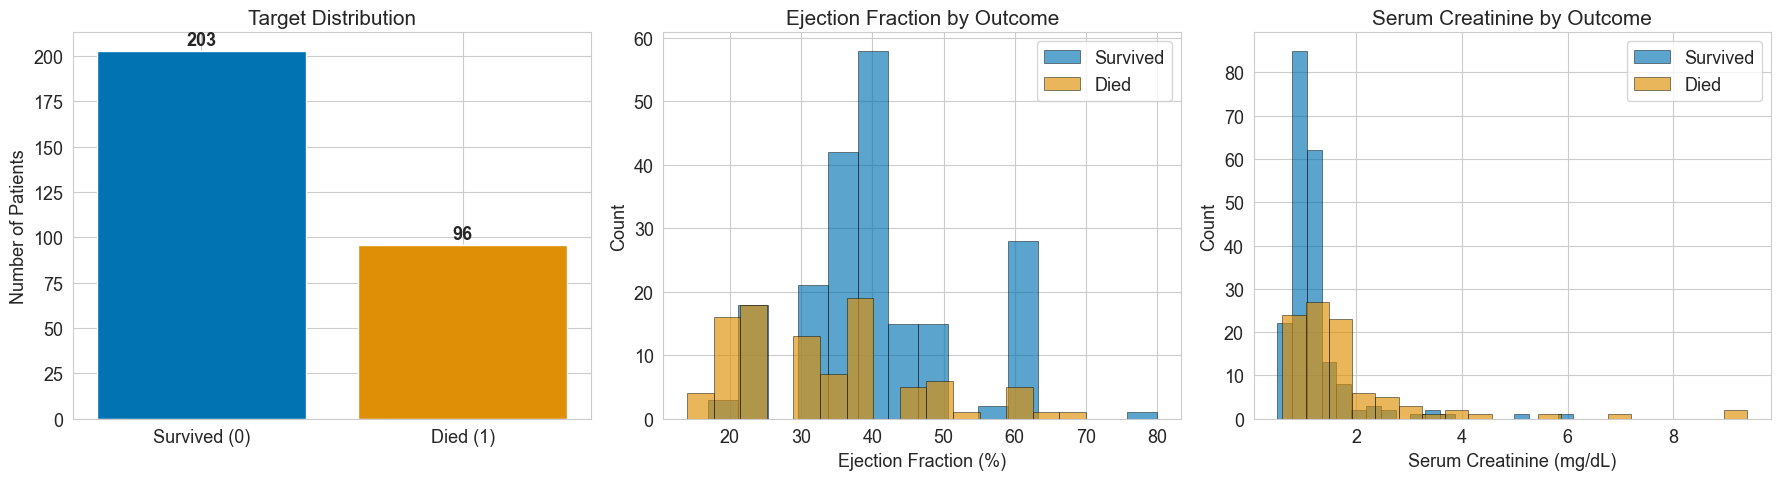

Alt-text: Three histograms showing target class balance, ejection fraction, and serum creatinine distributions split by survival outcome.


In [4]:
# ── Exploratory Visualisations ────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target distribution
counts = df["DEATH_EVENT"].value_counts()
axes[0].bar(["Survived (0)", "Died (1)"], counts.values,
            color=[CB_PALETTE[0], CB_PALETTE[1]])
axes[0].set_title("Target Distribution")
axes[0].set_ylabel("Number of Patients")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha="center", fontweight="bold")

# 2. Ejection fraction by outcome
for label, colour in zip([0, 1], [CB_PALETTE[0], CB_PALETTE[1]]):
    subset = df[df["DEATH_EVENT"] == label]["ejection_fraction"]
    axes[1].hist(subset, bins=15, alpha=0.65, label=f"{'Survived' if label==0 else 'Died'}",
                 color=colour, edgecolor="black", linewidth=0.5)
axes[1].set_title("Ejection Fraction by Outcome")
axes[1].set_xlabel("Ejection Fraction (%)")
axes[1].set_ylabel("Count")
axes[1].legend()

# 3. Serum creatinine by outcome
for label, colour in zip([0, 1], [CB_PALETTE[0], CB_PALETTE[1]]):
    subset = df[df["DEATH_EVENT"] == label]["serum_creatinine"]
    axes[2].hist(subset, bins=20, alpha=0.65, label=f"{'Survived' if label==0 else 'Died'}",
                 color=colour, edgecolor="black", linewidth=0.5)
axes[2].set_title("Serum Creatinine by Outcome")
axes[2].set_xlabel("Serum Creatinine (mg/dL)")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.savefig("figures/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Alt-text: Three histograms showing target class balance, ejection fraction, and serum creatinine distributions split by survival outcome.")

/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


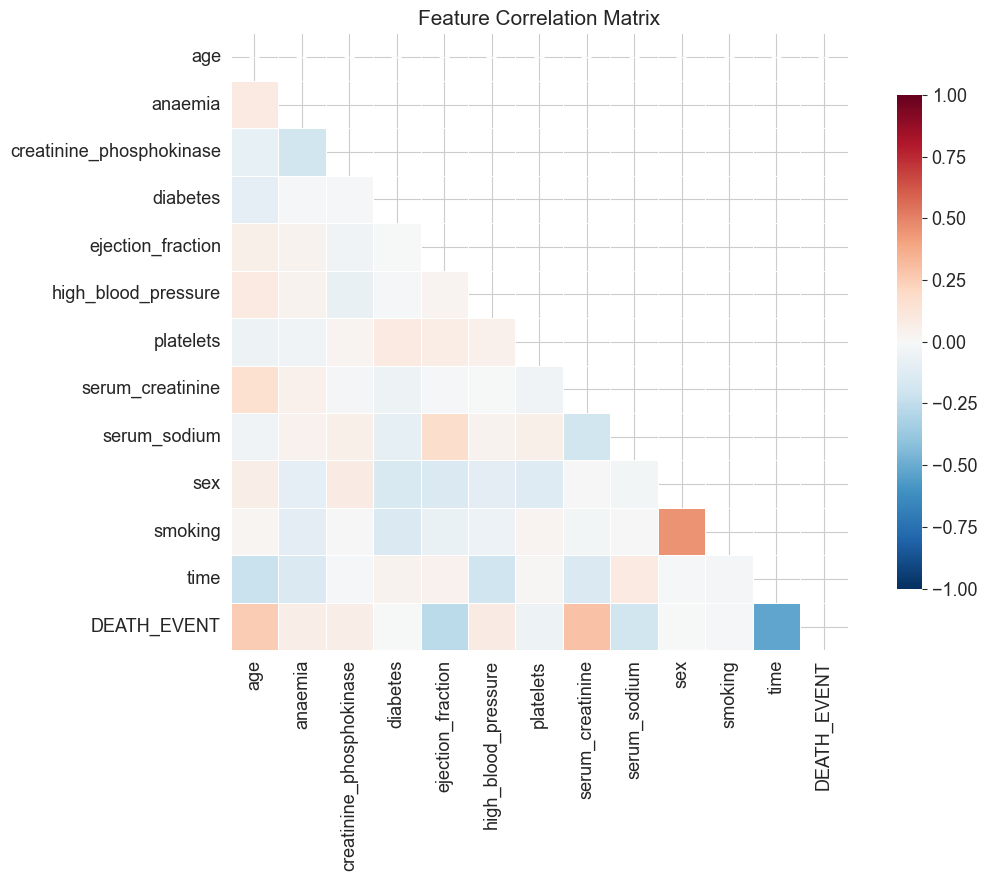

Alt-text: Heatmap showing pairwise Pearson correlations between all features. Time and serum_creatinine show the strongest correlations with DEATH_EVENT.


In [5]:
# ── Correlation Heatmap ──────────────────────────────────────────────
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Alt-text: Heatmap showing pairwise Pearson correlations between all features. Time and serum_creatinine show the strongest correlations with DEATH_EVENT.")

## 3. Preprocessing

Tree-based models (Decision Trees, Random Forests, Gradient Boosting) do **not** require feature scaling because they split on thresholds, not distances. This is one of their practical advantages over methods like SVM or k-NN.

We split the data **80/20** with stratification to preserve the class ratio in both sets.

In [6]:
# ── Train / Test Split ───────────────────────────────────────────────
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTrain class ratio: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test class ratio:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

Training set: 239 samples
Test set:     60 samples

Train class ratio: {0: 0.678, 1: 0.322}
Test class ratio:  {0: 0.683, 1: 0.317}


## 4. Baseline: Decision Tree

We start with a single Decision Tree to establish a baseline. This lets us see how much improvement ensemble methods (Random Forest, Gradient Boosting) provide.

In [7]:
# ── Decision Tree ────────────────────────────────────────────────────
dt = DecisionTreeClassifier(random_state=SEED, max_depth=4)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Results")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_dt):.3f}")
print(f"\n{classification_report(y_test, y_pred_dt, target_names=['Survived', 'Died'])}")

Decision Tree Results
Accuracy: 0.750
F1 Score: 0.516

              precision    recall  f1-score   support

    Survived       0.77      0.90      0.83        41
        Died       0.67      0.42      0.52        19

    accuracy                           0.75        60
   macro avg       0.72      0.66      0.67        60
weighted avg       0.74      0.75      0.73        60



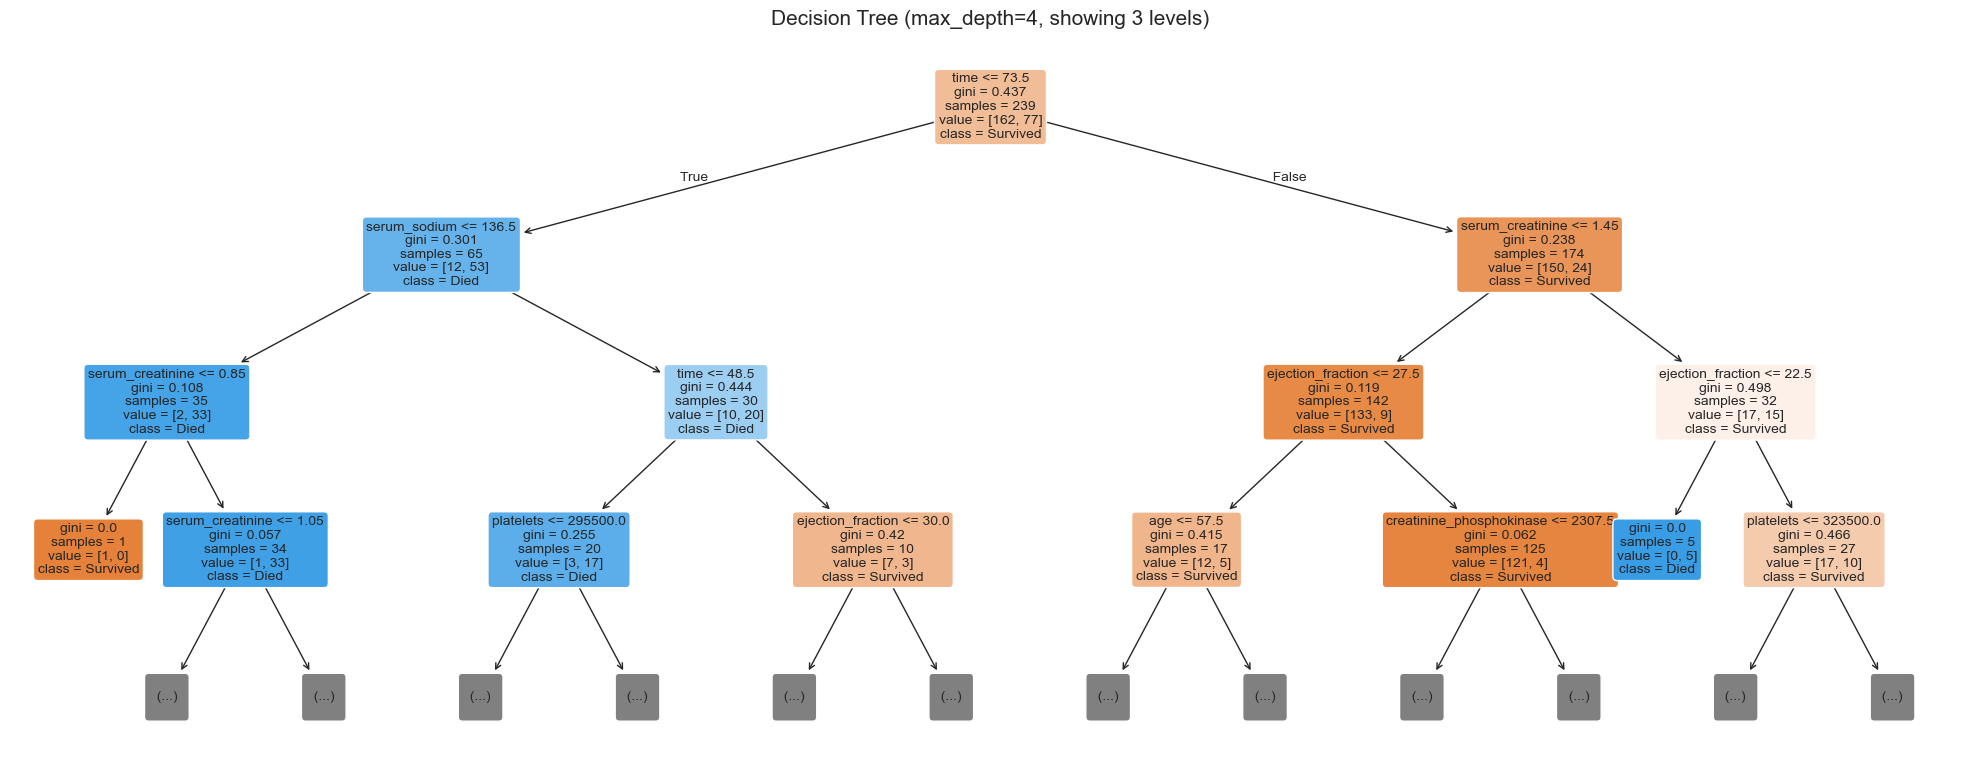

Alt-text: A decision tree diagram showing how the model splits on features like time, serum_creatinine, and ejection_fraction to classify survival.


In [8]:
# Visualise the Decision Tree (limited depth for readability)
plt.figure(figsize=(20, 8))
plot_tree(dt, feature_names=X.columns, class_names=["Survived", "Died"],
          filled=True, rounded=True, fontsize=10, max_depth=3)
plt.title("Decision Tree (max_depth=4, showing 3 levels)")
plt.tight_layout()
plt.savefig("figures/decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()
print("Alt-text: A decision tree diagram showing how the model splits on features like time, serum_creatinine, and ejection_fraction to classify survival.")

## 5. Random Forest (Bagging)

A Random Forest (Breiman, 2001) trains **many decision trees** on random subsets of the data and features, then combines their predictions by majority voting. This reduces variance and typically improves over a single tree.

Key parameters:
- `n_estimators`: number of trees (more = better, but diminishing returns)
- `max_features`: how many features each tree considers at each split (adds randomness)

In [9]:
# ── Random Forest ────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.3f}")
print(f"\n{classification_report(y_test, y_pred_rf, target_names=['Survived', 'Died'])}")

Random Forest Results
Accuracy: 0.817
F1 Score: 0.667

              precision    recall  f1-score   support

    Survived       0.83      0.93      0.87        41
        Died       0.79      0.58      0.67        19

    accuracy                           0.82        60
   macro avg       0.81      0.75      0.77        60
weighted avg       0.81      0.82      0.81        60



## 6. How Gradient Boosting Works — Step by Step

This is the core concept of the tutorial. Gradient Boosting (Friedman, 2001) builds an ensemble **sequentially**, where each tree corrects the mistakes of the combined model so far.

### The Algorithm (Simplified)

1. **Start with a simple prediction** — e.g., the average of the target (for regression) or the log-odds (for classification).
2. **Compute residuals** — the difference between actual values and current predictions. These residuals represent what the model still gets wrong.
3. **Fit a small tree to the residuals** — this tree learns to predict the *errors*, not the original target.
4. **Update the prediction** — add the new tree's output (scaled by a *learning rate* η) to the running prediction.
5. **Repeat** steps 2–4 for `n_estimators` rounds.

### Why "Gradient"?

The residuals are actually the **negative gradient** of the loss function. By fitting trees to gradients, the method performs **gradient descent in function space** — each tree takes a step that reduces the overall loss.

### The Learning Rate (η)

The learning rate controls how much each tree contributes. A smaller η means each tree has less influence, requiring more trees but often producing better generalisation — this is the **shrinkage** technique.

```
prediction = initial_prediction
for each round:
    residuals = actual - prediction
    new_tree  = fit_tree(residuals)
    prediction += η × new_tree(X)
```

Let's demonstrate this with a simple visual example below.

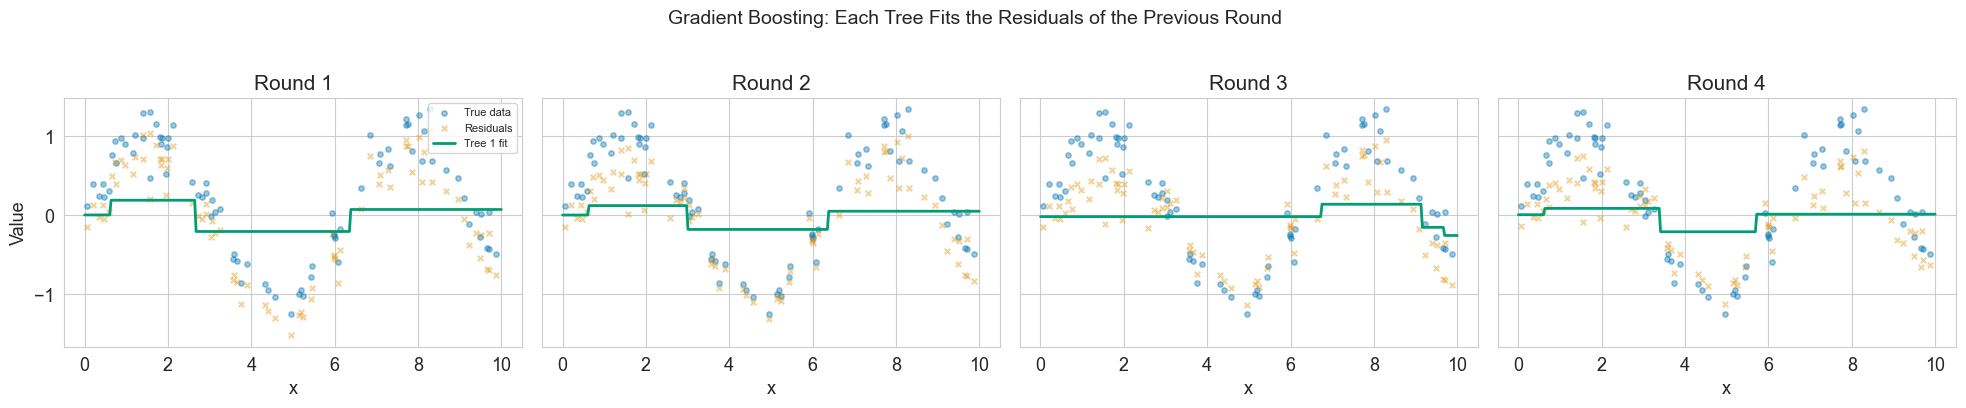

Alt-text: Four subplots showing gradient boosting rounds. Each round shows the data points, current residuals (x markers), and the new tree's fit to those residuals. Residuals decrease with each round.


In [10]:
# ── Manual Gradient Boosting Demo (Regression on a 1-D toy problem) ──
# This illustrates the residual-fitting concept visually.

from sklearn.tree import DecisionTreeRegressor

# Create a simple 1-D dataset: y = sin(x) + noise
np.random.seed(SEED)
X_demo = np.sort(np.random.uniform(0, 10, 80)).reshape(-1, 1)
y_demo = np.sin(X_demo.ravel()) + np.random.normal(0, 0.2, 80)

learning_rate = 0.3
n_rounds = 4

fig, axes = plt.subplots(1, n_rounds, figsize=(20, 4), sharey=True)
X_plot = np.linspace(0, 10, 300).reshape(-1, 1)

# Initial prediction: mean of y
prediction = np.full_like(y_demo, y_demo.mean())

for i in range(n_rounds):
    residuals = y_demo - prediction
    
    # Fit a shallow tree to the residuals
    tree = DecisionTreeRegressor(max_depth=2, random_state=SEED)
    tree.fit(X_demo, residuals)
    
    # Update prediction
    update = learning_rate * tree.predict(X_demo)
    prediction += update
    
    # Plot
    axes[i].scatter(X_demo, y_demo, alpha=0.4, s=15, color=CB_PALETTE[0], label="True data")
    axes[i].scatter(X_demo, residuals, alpha=0.4, s=15, color=CB_PALETTE[1], label="Residuals", marker="x")
    axes[i].plot(X_plot, learning_rate * tree.predict(X_plot), color=CB_PALETTE[2],
                 linewidth=2, label=f"Tree {i+1} fit")
    axes[i].set_title(f"Round {i+1}")
    axes[i].set_xlabel("x")
    if i == 0:
        axes[i].set_ylabel("Value")
        axes[i].legend(fontsize=8, loc="upper right")

plt.suptitle("Gradient Boosting: Each Tree Fits the Residuals of the Previous Round",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("figures/gradient_boosting_demo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Alt-text: Four subplots showing gradient boosting rounds. Each round shows the data points, current residuals (x markers), and the new tree's fit to those residuals. Residuals decrease with each round.")

## 7. XGBoost in Practice

**XGBoost** (eXtreme Gradient Boosting) was introduced by Chen and Guestrin (2016) and is the most widely used implementation of gradient boosting. It adds several improvements over the basic algorithm described by Friedman (2001):

| Feature | Benefit |
|---|---|
| **L1 & L2 regularisation** (Chen and Guestrin, 2016) | Prevents overfitting by penalising complex trees |
| **Column subsampling** | Like Random Forest — uses random feature subsets |
| **Built-in missing value handling** | Learns optimal directions for missing values |
| **Parallel computation** | Speeds up training despite sequential nature |
| **Early stopping** | Stops adding trees when validation performance plateaus |

### Key Hyperparameters

- `n_estimators`: Number of boosting rounds (trees)
- `max_depth`: Maximum depth of each tree (controls complexity)
- `learning_rate` (η): Step size shrinkage — lower values need more trees but generalise better (Friedman, 2001)
- `subsample`: Fraction of training data used per tree (stochastic gradient boosting)
- `colsample_bytree`: Fraction of features used per tree

In [11]:
# ── XGBoost (default parameters) ─────────────────────────────────────
xgb_default = XGBClassifier(
    n_estimators=100,
    random_state=SEED,
    eval_metric="logloss",
)
xgb_default.fit(X_train, y_train)
y_pred_xgb = xgb_default.predict(X_test)

print("XGBoost (Default) Results")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.3f}")
print(f"\n{classification_report(y_test, y_pred_xgb, target_names=['Survived', 'Died'])}")

XGBoost (Default) Results
Accuracy: 0.817
F1 Score: 0.645

              precision    recall  f1-score   support

    Survived       0.81      0.95      0.88        41
        Died       0.83      0.53      0.65        19

    accuracy                           0.82        60
   macro avg       0.82      0.74      0.76        60
weighted avg       0.82      0.82      0.80        60



## 8. Hyperparameter Tuning with Grid Search

Default XGBoost already performs well, but we can often improve by tuning hyperparameters. We use **GridSearchCV** with 5-fold cross-validation to find the best combination.

We tune three critical parameters:
- `max_depth` — controls tree complexity
- `learning_rate` — controls the contribution of each tree  
- `n_estimators` — number of boosting rounds

In [12]:
# ── Hyperparameter Tuning ────────────────────────────────────────────
param_grid = {
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [50, 100, 200],
    "subsample": [0.8, 1.0],
}

xgb_tuned = XGBClassifier(
    random_state=SEED,
    eval_metric="logloss",
)

grid_search = GridSearchCV(
    xgb_tuned, param_grid,
    cv=5, scoring="f1", n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print("Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation F1: {grid_search.best_score_:.3f}")

# Evaluate tuned model on test set
y_pred_xgb_tuned = grid_search.best_estimator_.predict(X_test)
print(f"\nTuned XGBoost Test Results")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_tuned):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb_tuned):.3f}")
print(f"\n{classification_report(y_test, y_pred_xgb_tuned, target_names=['Survived', 'Died'])}")

Best parameters found:
  learning_rate: 0.1
  max_depth: 3
  n_estimators: 100
  subsample: 0.8

Best cross-validation F1: 0.770

Tuned XGBoost Test Results
Accuracy: 0.833
F1 Score: 0.688

              precision    recall  f1-score   support

    Survived       0.83      0.95      0.89        41
        Died       0.85      0.58      0.69        19

    accuracy                           0.83        60
   macro avg       0.84      0.77      0.79        60
weighted avg       0.83      0.83      0.82        60



## 9. Model Comparison & Feature Importance

Now let's compare all four models side by side and examine which features XGBoost considers most important for predicting heart failure survival.

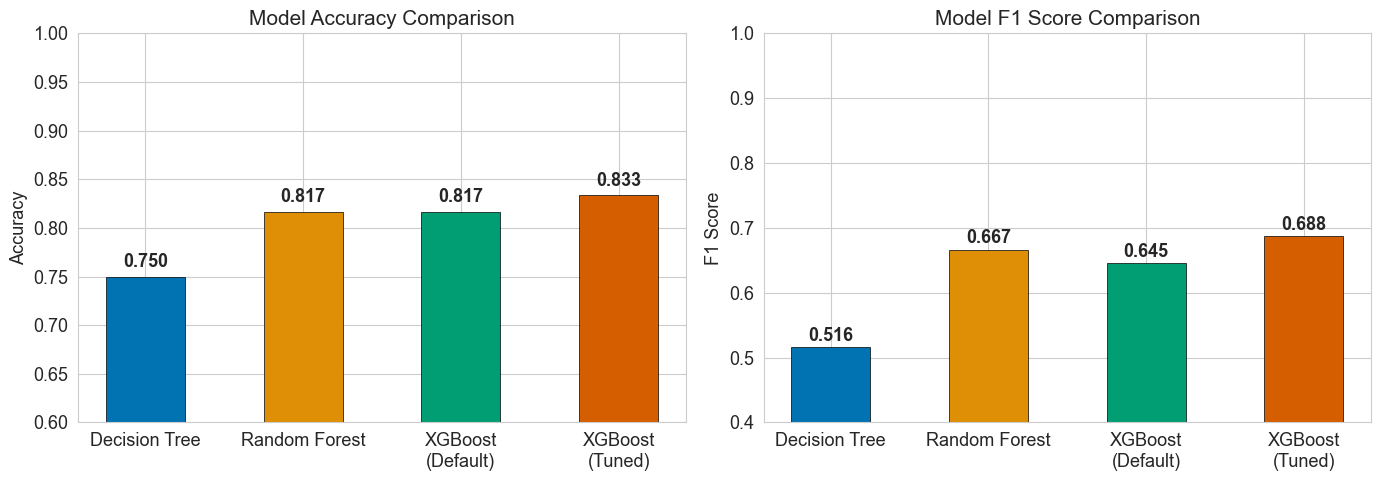

Alt-text: Two bar charts comparing accuracy and F1 scores across Decision Tree, Random Forest, XGBoost Default, and XGBoost Tuned models.


In [13]:
# ── Model Comparison Bar Chart ───────────────────────────────────────
models = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost\n(Default)": y_pred_xgb,
    "XGBoost\n(Tuned)": y_pred_xgb_tuned,
}

accuracies = [accuracy_score(y_test, pred) for pred in models.values()]
f1_scores = [f1_score(y_test, pred) for pred in models.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(models))
width = 0.5

# Accuracy comparison
bars1 = axes[0].bar(x, accuracies, width, color=CB_PALETTE[:4], edgecolor="black", linewidth=0.5)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models.keys())
axes[0].set_ylim(0.6, 1.0)
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontweight="bold")

# F1 comparison
bars2 = axes[1].bar(x, f1_scores, width, color=CB_PALETTE[:4], edgecolor="black", linewidth=0.5)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Model F1 Score Comparison")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models.keys())
axes[1].set_ylim(0.4, 1.0)
for bar, val in zip(bars2, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Alt-text: Two bar charts comparing accuracy and F1 scores across Decision Tree, Random Forest, XGBoost Default, and XGBoost Tuned models.")

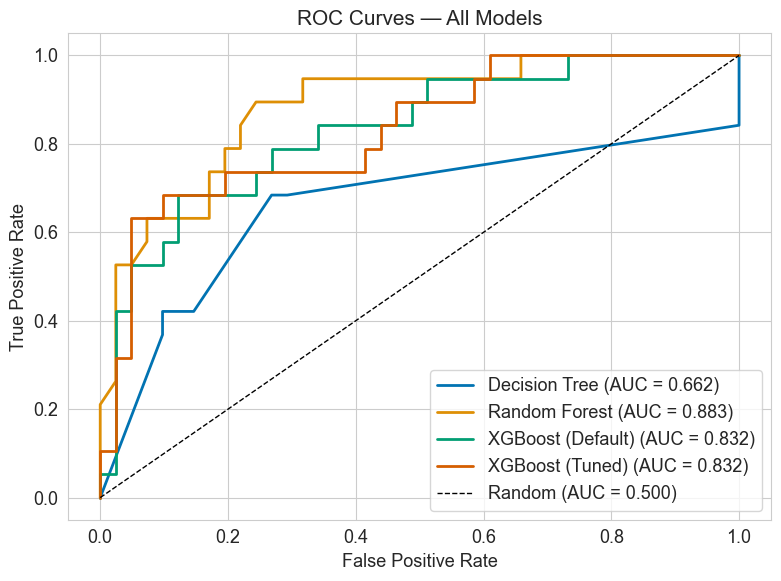

Alt-text: ROC curves for all four models. XGBoost models achieve the highest AUC, followed by Random Forest, then Decision Tree.


In [14]:
# ── ROC Curves ──────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

# Get probability predictions for ROC
classifiers = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost (Default)": xgb_default,
    "XGBoost (Tuned)": grid_search.best_estimator_,
}

for i, (name, clf) in enumerate(classifiers.items()):
    y_proba = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=CB_PALETTE[i], linewidth=2,
             label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Alt-text: ROC curves for all four models. XGBoost models achieve the highest AUC, followed by Random Forest, then Decision Tree.")

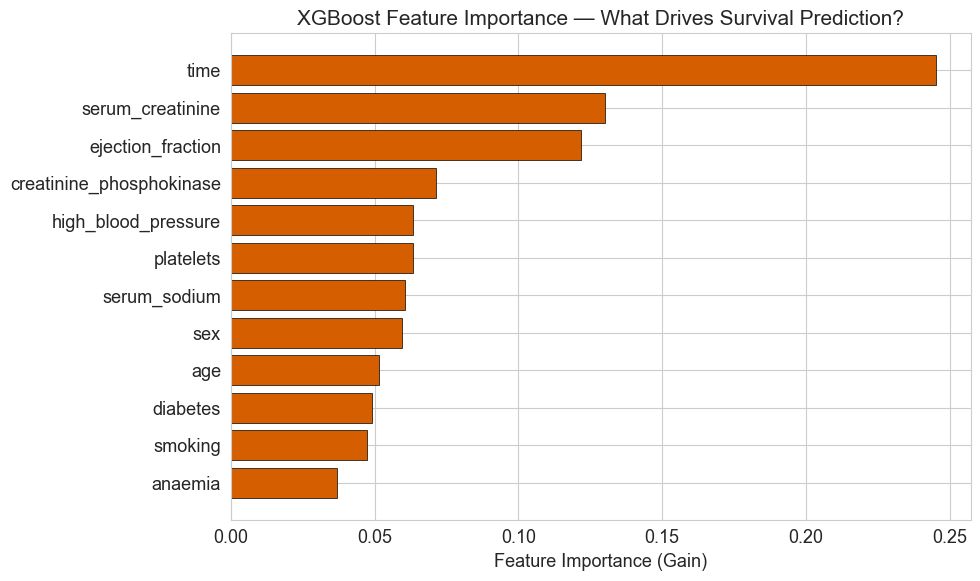

Alt-text: Horizontal bar chart showing XGBoost feature importance. Time, serum_creatinine, and ejection_fraction are typically the most important features.


In [15]:
# ── Feature Importance (Tuned XGBoost) ──────────────────────────────
best_xgb = grid_search.best_estimator_
importances = best_xgb.feature_importances_
feature_names = X.columns
sorted_idx = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), importances[sorted_idx],
         color=CB_PALETTE[3], edgecolor="black", linewidth=0.5)
plt.yticks(range(len(sorted_idx)), feature_names[sorted_idx])
plt.xlabel("Feature Importance (Gain)")
plt.title("XGBoost Feature Importance — What Drives Survival Prediction?")
plt.tight_layout()
plt.savefig("figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Alt-text: Horizontal bar chart showing XGBoost feature importance. Time, serum_creatinine, and ejection_fraction are typically the most important features.")

## 10. Key Takeaways — When to Use Gradient Boosting

### What we learned

1. **Decision Trees** are fast and interpretable but prone to overfitting.
2. **Random Forests** (bagging) reduce variance by averaging many independent trees (Breiman, 2001).
3. **Gradient Boosting** reduces bias by sequentially fitting trees to residuals — each tree corrects the previous model's mistakes (Friedman, 2001).
4. **XGBoost** adds regularisation, column subsampling, and parallelism to make gradient boosting practical and powerful (Chen and Guestrin, 2016).
5. **Hyperparameter tuning** (especially `learning_rate`, `max_depth`, `n_estimators`) is critical for gradient boosting to avoid overfitting.

### When to choose Gradient Boosting

| Use Gradient Boosting when... | Consider alternatives when... |
|---|---|
| You need maximum predictive accuracy | You need a simple, interpretable model |
| You have structured/tabular data | You have image, text, or sequence data (use deep learning) |
| You can afford time for hyperparameter tuning | You need a quick baseline (use Random Forest) |
| Your dataset is small to medium-sized | Your dataset is extremely large (training can be slow) |

### Practical tips
- **Start with a low learning rate** (0.01–0.1) and increase `n_estimators` accordingly (Friedman, 2001).
- **Use early stopping** to prevent overfitting — stop training when validation performance stops improving (Chen and Guestrin, 2016).
- **Monitor the gap** between training and validation scores — a large gap signals overfitting.
- **Feature importance** from XGBoost can guide feature engineering and domain understanding (Chen and Guestrin, 2016).

---

## References

1. Chen, T. and Guestrin, C. (2016) 'XGBoost: A Scalable Tree Boosting System', *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, pp. 785–794. doi:10.1145/2939672.2939785.
2. Friedman, J.H. (2001) 'Greedy Function Approximation: A Gradient Boosting Machine', *The Annals of Statistics*, 29(5), pp. 1189–1232.
3. Chicco, D. and Jurman, G. (2020) 'Machine learning can predict survival of patients with heart failure from serum creatinine and ejection fraction alone', *BMC Medical Informatics and Decision Making*, 20(16). doi:10.1186/s12911-020-1023-5.
4. Scikit-learn developers (2024) *Ensemble Methods — scikit-learn documentation*. Available at: https://scikit-learn.org/stable/modules/ensemble.html (Accessed: 15 March 2026).
5. XGBoost developers (2024) *XGBoost Documentation*. Available at: https://xgboost.readthedocs.io/ (Accessed: 15 March 2026).
6. Breiman, L. (2001) 'Random Forests', *Machine Learning*, 45(1), pp. 5–32. doi:10.1023/A:1010933404324.
7. UCI Machine Learning Repository (2020) *Heart Failure Clinical Records Dataset*. Available at: https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records (Accessed: 15 March 2026).
